#Automating Text Vectorization

In [1]:
#Import required librairies
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Flatten,Embedding,LSTM,GRU
from tensorflow.keras.layers import TextVectorization, InputLayer
import tensorflow as tf

In [2]:
max_words = 10000
max_length = 500

model = Sequential()
model.add(InputLayer(shape=(1,), dtype=tf.string))
model.add(TextVectorization(max_tokens=max_words, output_sequence_length=max_length))
model.add(Embedding(max_words, 32))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ (None, 500)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 500, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,048,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,368,257 (9.03 MB)

 Trainable params: 2,368,257 (9.03 MB)

 Non-trainable params: 0 (0.00 B)

In [3]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/reviews.csv', encoding="ISO-8859-1")
df = df.sample(frac=1, random_state=0)
df.head()

,Text,Sentiment
11841,Al Pacino was once an actor capable of making ...,0
19602,After Chaplin made one of his best films: Doug...,0
45519,This movie is sort of a Carrie meets Heavy Met...,1
25747,I have fond memories of watching this visually...,1
42642,"In the '70s, Charlton Heston starred in sci-fi...",1


In [4]:
#Remove duplicate rows
df=df.drop_duplicates()

In [5]:
df.groupby("Sentiment").describe()

Text                                                            \
           count unique                                                top   
Sentiment                                                                    
0          24697  24697  What could've been a great film about the late...   
1          24884  24884  I really enjoyed this film. All aspects of the...   

                
          freq  
Sentiment       
0            1  
1            1

In [6]:
#Split the dataset
x=df["Text"]
y=df["Sentiment"]
model.layers[0].adapt(x)

In [7]:
hist = model.fit(tf.constant(x), y, validation_split=0.5, epochs=5, batch_size=250)


Epoch 1/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 22s 213ms/step - accuracy: 0.7159 - loss: 0.5221 - val_accuracy: 0.8253 - val_loss: 0.3822
Epoch 2/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 18s 185ms/step - accuracy: 0.9113 - loss: 0.2257 - val_accuracy: 0.8003 - val_loss: 0.4582
Epoch 3/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 20s 178ms/step - accuracy: 0.9735 - loss: 0.0946 - val_accuracy: 0.8508 - val_loss: 0.3854
Epoch 4/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 17s 173ms/step - accuracy: 0.9960 - loss: 0.0252 - val_accuracy: 0.8522 - val_loss: 0.4436
Epoch 5/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 17s 174ms/step - accuracy: 0.9993 - loss: 0.0081 - val_accuracy: 0.8494 - val_loss: 0.4943


[]

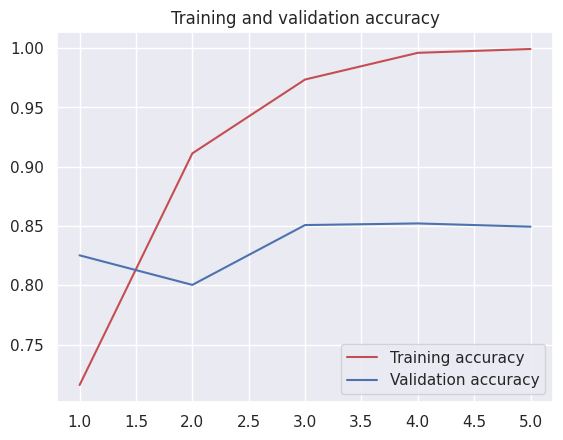

In [8]:
from numpy import e
import seaborn as sns
import matplotlib.pyplot as plt
sns.set()

acc=hist.history['accuracy']
val_acc=hist.history['val_accuracy']
epochs=range(1, len(acc)+1)

plt.plot(epochs, acc, 'r', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend(loc='lower right')
plt.plot()

In [9]:
#Make a prediction
text="Excellent foof and fantastic service"
model.predict(tf.constant([text]))[0][0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step


np.float32(0.9961248)

In [10]:
model.save("sentiment_model.keras")           # saves as a folder


#LSTM for Text classification

In [11]:
max_words = 10000
max_length = 500

model_lstm = Sequential()
model_lstm.add(InputLayer(shape=(1,), dtype=tf.string))
model_lstm.add(TextVectorization(max_tokens=max_words, output_sequence_length=max_length))
model_lstm.add(Embedding(max_words, 32))
model_lstm.add(LSTM(32))
model_lstm.add(Dense(1, activation='sigmoid'))

model_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_lstm.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization_1            │ (None, 500)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (None, 500, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 328,353 (1.25 MB)

 Trainable params: 328,353 (1.25 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model_lstm.layers[0].adapt(x)

In [13]:
hist = model_lstm.fit(tf.constant(x), y, validation_split=0.5, epochs=5, batch_size=250)


Epoch 1/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 61s 586ms/step - accuracy: 0.5020 - loss: 0.6933 - val_accuracy: 0.5039 - val_loss: 0.6929
Epoch 2/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 82s 583ms/step - accuracy: 0.5083 - loss: 0.6924 - val_accuracy: 0.5061 - val_loss: 0.6934
Epoch 3/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 64s 641ms/step - accuracy: 0.5148 - loss: 0.6870 - val_accuracy: 0.5086 - val_loss: 0.6920
Epoch 4/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 58s 587ms/step - accuracy: 0.5464 - loss: 0.6792 - val_accuracy: 0.4995 - val_loss: 0.6955
Epoch 5/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 58s 586ms/step - accuracy: 0.5314 - loss: 0.6812 - val_accuracy: 0.5031 - val_loss: 0.6941


[]

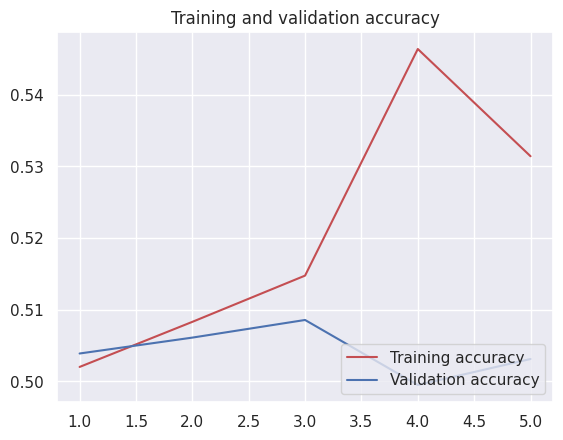

In [14]:
from numpy import e
import seaborn as sns
import matplotlib.pyplot as plt
sns.set()

acc=hist.history['accuracy']
val_acc=hist.history['val_accuracy']
epochs=range(1, len(acc)+1)

plt.plot(epochs, acc, 'r', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend(loc='lower right')
plt.plot()

#GRU for text classification

In [15]:
model_gru = Sequential()
model_gru.add(InputLayer(shape=(1,), dtype=tf.string))
model_gru.add(TextVectorization(max_tokens=max_words, output_sequence_length=max_length))
model_gru.add(Embedding(max_words, 32))
model_gru.add(GRU(32))          # ← seul changement
model_gru.add(Dense(1, activation='sigmoid'))

model_gru.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_gru.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization_2            │ (None, 500)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_2 (Embedding)         │ (None, 500, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 32)             │         6,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 326,369 (1.24 MB)

 Trainable params: 326,369 (1.24 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
hist = model_lstm.fit(tf.constant(x), y, validation_split=0.5, epochs=5, batch_size=250)


Epoch 1/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 58s 586ms/step - accuracy: 0.5370 - loss: 0.6647 - val_accuracy: 0.5057 - val_loss: 0.6926
Epoch 2/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 82s 583ms/step - accuracy: 0.5395 - loss: 0.6563 - val_accuracy: 0.5101 - val_loss: 0.7041
Epoch 3/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 58s 582ms/step - accuracy: 0.5371 - loss: 0.6511 - val_accuracy: 0.5089 - val_loss: 0.7110
Epoch 4/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 82s 582ms/step - accuracy: 0.5433 - loss: 0.6445 - val_accuracy: 0.5088 - val_loss: 0.7221
Epoch 5/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 83s 587ms/step - accuracy: 0.5328 - loss: 0.6445 - val_accuracy: 0.5144 - val_loss: 0.7063


[]

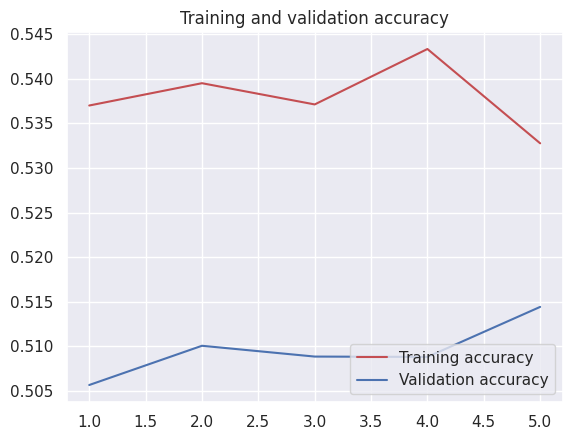

In [17]:
from numpy import e
import seaborn as sns
import matplotlib.pyplot as plt
sns.set()

acc=hist.history['accuracy']
val_acc=hist.history['val_accuracy']
epochs=range(1, len(acc)+1)

plt.plot(epochs, acc, 'r', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend(loc='lower right')
plt.plot()